In [1]:
import numpy as np
import matplotlib.pyplot as plt
import OptimalBattery.util as ut
import os
import PcmPy as pcm
import seaborn as sns
import pandas as pd
import OptimalBattery.evaluate as ev
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetMDTB
from IndividualParcellation.global_config import *
import nilearn.plotting as plotting
import nitools as nt
import nibabel as nb
import OptimalBattery.estimate as es
import OptimalBattery.construct as ct
import OptimalBattery.plot as plot


Default device set to: cuda


# define atlas and dirs

In [2]:
space = 'fs32k'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/'

func_fus_dir = os.path.join(base_dir, 'FunctionalFusion')
cerebellum_dir = os.path.join(base_dir, 'Cerebellum')

In [3]:
  # Load surface files for left and right hemispheres
surfs = [f"{func_fus_dir}/Atlases/tpl-fs32k/tpl-fs32k_hemi-{h}_inflated.surf.gii" for h in ['L', 'R']]
def plot_cortex(data, threshold=0.0, cmap='binary', figsize=(12, 6)):  

    # Convert data to CIFTI format
    cifti = atlas.data_to_cifti(data)
    
    # Extract data for the cortical surfaces
    all_img = nt.surf_from_cifti(cifti)
    
    # Create the plot
    fig, axes = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=figsize)
    for h, hemi in enumerate(['left', 'right']):
        plotting.plot_surf_stat_map(
            surfs[h], all_img[h], hemi=hemi,
            colorbar=False,
            cmap=cmap,
            axes=axes[h],
            threshold=threshold,
            title=f'figure {h+1}'
        )
    
    return fig

In [4]:
# Load glasser atlas
# roi (prefrontal cortex)
atlas_dir = f'{func_fus_dir}/Atlases/tpl-fs32k'
model_name_L = f'{atlas_dir}/glasser.L.label.gii'
model_name_R = f'{atlas_dir}/glasser.R.label.gii'
glasser_atlas = atlas.read_data([model_name_L,model_name_R])


# Load data

In [ ]:
MDTB_dataset = DataSetMDTB(f'{func_fus_dir}/MDTB')


data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0


data_mdtb_s1_all,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondAll')
data_mdtb_s1_all[np.isnan(data_mdtb_s1_all)] = 0



data_mdtb_s2_all,info_mdtb_2_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
data_mdtb_s2_all[np.isnan(data_mdtb_s2_all)] = 0


In [ ]:
data_mdtb_s1_run = ut.recenter_fmri_data(data_mdtb_s1_run,info_mdtb_1_run,task_column_name='cond_name',center_condition='rest')
data_mdtb_s1_all = ut.recenter_fmri_data(data_mdtb_s1_all,info_mdtb_1_all,task_column_name='cond_name',center_condition='rest')


# run loop

In [ ]:

rois = {
    "orbitofrontal": [
    "10pp", "10r", "10d", "10v", "a10p", "p10p", "OFC", "pOFC",
    "11l", "13l", "25", "p32", "a32pr", "s32", "p24", "a24",
     "47m", "47s"],
    'Dorsolateral_PFC': ['9-46d', '46', '9a', 'a9-46v', 'p9-46v', '9p', 'IFJa', 'IFJp', 'IFSp', 'IFSa'],
    'combined': ["10pp", "10r", "10d", "10v", "a10p", "p10p", "OFC", "pOFC",
    "11l", "13l", "25", "p32", "a32pr", "s32", "p24", "a24",
     "47m", "47s",'9-46d', '46', '9a', 'a9-46v', 'p9-46v', '9p', 'IFJa', 'IFJp', 'IFSp', 'IFSa']
}


In [ ]:
len(rois)

3

In [71]:
condition_df= ct.get_condition_indices(info_mdtb_1_run)
battery_sizes = [3,4,5,6,7,8,10]
metrics = ['variance','variance_mc','log_det_mc']

i = 0
results_df = []
for roi_name , parcels in rois.items():
    print(f'Processing {roi_name}')
    # define PFC parcel and get the indices of the PFC parcels

    # Load the GIFTI file
    gifti_data = nb.load(model_name_L)
    parcel_names = [label.label for label in gifti_data.labeltable.labels]
    parcel_names = [name[len("L_"):] if name.startswith("L_") else name for name in parcel_names]
    parcel_names = [name[:-len("_ROI")] if name.endswith("_ROI") else name for name in parcel_names]

    # Get the indices of the PFC parcels
    ROI_cortex = []
    for name in parcels:
        ROI_cortex.append(parcel_names.index(name))

    ROI_mask = np.isin(glasser_atlas, ROI_cortex).astype(int)
    mask_reshaped = ROI_mask[np.newaxis, :]  # Reshape to (1, 59518)
    ROI_indices = np.where(ROI_mask == 1)[0]

    cond_vec = np.tile(np.arange(1, 32 + 1), 16)
    part_vec = np.repeat(np.arange(1, 16 + 1), 32)
    Gs_list = []
    E_list = []
    for i in range(data_mdtb_s1_run.shape[0]):
        Gs,E = pcm.util.est_G_crossval(data_mdtb_s1_run[i][:,ROI_indices] , cond_vec, part_vec)
        Gs_list.append(Gs)
        E_list.append(E)

    Gs_list = np.stack(Gs_list, 0)
    G_Lib = np.mean(Gs_list, axis=0)

    # make variables torch
    device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
    data_mdtb_s1_all = pt.tensor(data_mdtb_s1_all, dtype=pt.float32, device=device)
    data_test = pt.tensor(data_mdtb_s2_all, dtype=pt.float32, device=device)
    data_train = pt.tensor(data_mdtb_s1_run, dtype=pt.float32, device=device)
    parcelation = pt.tensor(glasser_atlas, dtype=pt.float32, device=device)
    ROI_mask = pt.tensor(ROI_mask, dtype=pt.float32, device=device)

    # estimate Vs for session 1 using s1 full data
    full_vs_train = es.estimate_Vs(data_mdtb_s1_all,parcellation=parcelation,ROI_mask= ROI_mask)
    full_vs_train = ut.center_matrix(full_vs_train,axis=0)
    full_vs_train = ut.normalize_matrix(full_vs_train,axis=0)

    # estimate Vs for session 2 using s2 full data
    full_vs_test = es.estimate_Vs(data_test,parcellation=parcelation,ROI_mask=ROI_mask)
    full_vs_test = ut.center_matrix(full_vs_test,axis=0)
    full_vs_test = ut.normalize_matrix(full_vs_test,axis=0)

    n_parcels = full_vs_train.shape[1]

    VLib = full_vs_train[:,:]
    Vtest = full_vs_test[:,:]

    for n_task in battery_sizes:
        D = ct.build_combinations(G_Lib, strategy='random',n_batteries=10000,n_tasks=n_task,seed=1,replacement=False,rest_idx=31)

        for metric in metrics:
            top_5 = D.nlargest(5, metric)
            top_5 = top_5.reset_index(drop=True)
            D_ev = ev.evluate_dataframe( D = top_5, condition_df= condition_df, YLib= data_train,
                                     VLib= VLib, Ytest= data_test, Vtest= Vtest,indices=ROI_indices,method='correlation')
            average_cos_mean = D_ev['cos_mean'].mean()

            # append all information to the results dataframe as a dictionary
            results_df.append({'roi':roi_name,'n_parcels':n_parcels,'n_task':n_task,'metric':metric,'average_cos_mean':average_cos_mean})

results_df = pd.DataFrame(results_df)



Processing orbitofrontal


c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\torch\utils\_device.py:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing Dorsolateral_PFC


c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\torch\utils\_device.py:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combined


c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\torch\utils\_device.py:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing combination: 0


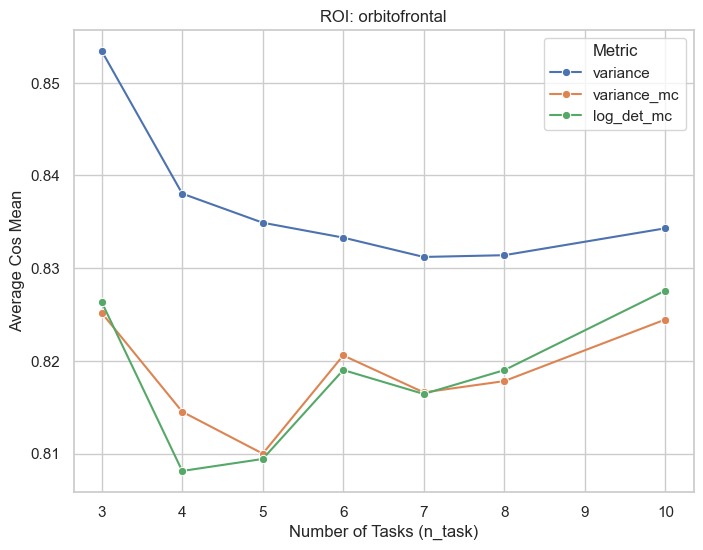

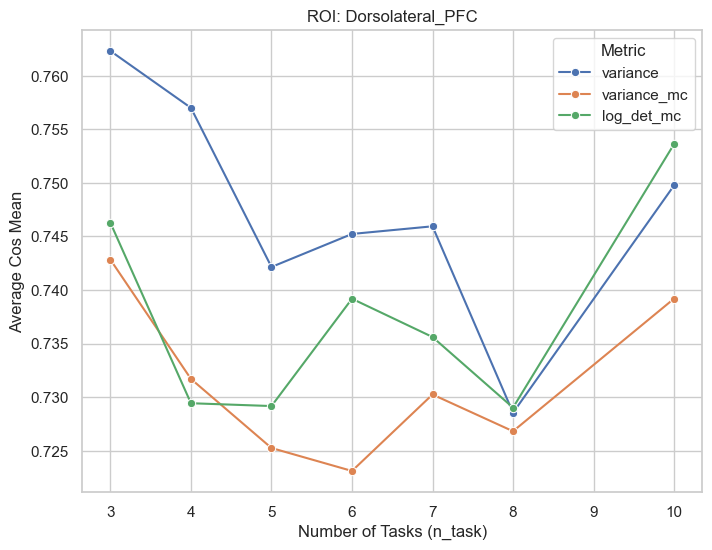

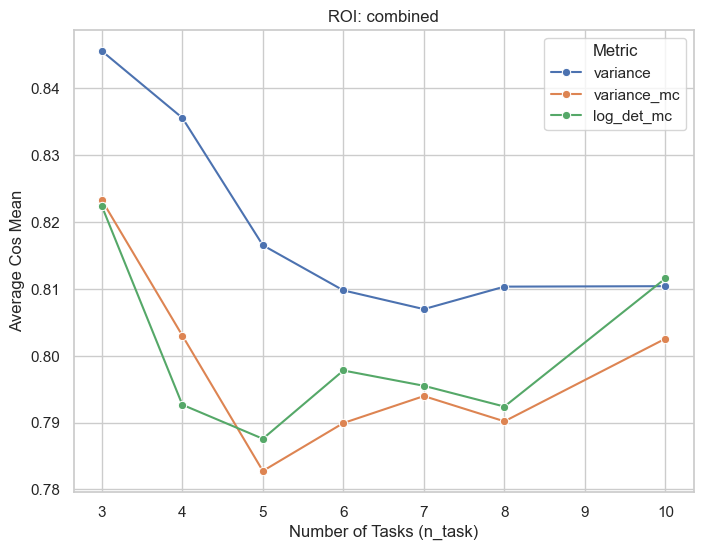

In [72]:

# Plotting
sns.set(style="whitegrid")
unique_rois = results_df["roi"].unique()
for roi in unique_rois:
    plt.figure(figsize=(8, 6))
    roi_df = results_df[results_df["roi"] == roi]
    
    sns.lineplot(data=roi_df, x="n_task", y="average_cos_mean", hue="metric", marker="o")
    plt.title(f"ROI: {roi}")
    plt.xlabel("Number of Tasks (n_task)")
    plt.ylabel("Average Cos Mean")
    plt.legend(title="Metric")
    plt.show()